# Тюнингуем модели 


In [1]:
import pandas as pd
import numpy as np

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/validation.parquet")

target = "is_canceled"

drop_cols = [
    target,
    "booking_date",
    "arrival_date"
]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

for col in categorical_cols:
    X_train[col] = X_train[col].astype("string")
    X_val[col] = X_val[col].astype("string")

In [3]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [4]:
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)

print(X_train_enc.shape)
print(X_val_enc.shape)

(82629, 239)
(18065, 239)


# LightGBM
Гиперпараметры подберем с помощью `Random search`

In [5]:
param_grid = {
    "num_leaves": [15, 31, 63, 95],
    "max_depth": [-1, 6, 8, 10],
    "min_child_samples": [20, 50, 100, 200],
    "learning_rate": [0.02, 0.05, 0.08],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0, 5.0]
}

In [6]:
from sklearn.model_selection import ParameterSampler

params_list = list(
    ParameterSampler(
        param_grid,
        n_iter=25,
        random_state=42
    )
)

len(params_list)

25

In [7]:
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

tuning_results = []

for i, params in enumerate(params_list, start=1):

    # Не используем слишком много leaves заранее
    # при ограниченной глубине
    if (
        params["max_depth"] > 0
        and params["num_leaves"] > 2 ** params["max_depth"]
    ):
        continue

    model = LGBMClassifier(
        n_estimators=3000,
        objective="binary",
        subsample_freq=1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params
    )

    model.fit(
        X_train_enc,
        y_train,
        eval_set=[(X_val_enc, y_val)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(
                100,
                verbose=False
            )
        ]
    )

    proba = model.predict_proba(X_val_enc)[:, 1]

    tuning_results.append({
        **params,
        "best_iteration": model.best_iteration_,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba)
    })

    print(
        f"{i}/{len(params_list)} | "
        f"ROC-AUC: {tuning_results[-1]['roc_auc']:.4f} | "
        f"PR-AUC: {tuning_results[-1]['pr_auc']:.4f}"
    )

e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


1/25 | ROC-AUC: 0.9238 | PR-AUC: 0.8968


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


2/25 | ROC-AUC: 0.9230 | PR-AUC: 0.8963


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


3/25 | ROC-AUC: 0.9233 | PR-AUC: 0.8968


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


4/25 | ROC-AUC: 0.9230 | PR-AUC: 0.8960


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


5/25 | ROC-AUC: 0.9221 | PR-AUC: 0.8949


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


6/25 | ROC-AUC: 0.9209 | PR-AUC: 0.8935


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


7/25 | ROC-AUC: 0.9230 | PR-AUC: 0.8962


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


8/25 | ROC-AUC: 0.9213 | PR-AUC: 0.8940


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


9/25 | ROC-AUC: 0.9228 | PR-AUC: 0.8960


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


10/25 | ROC-AUC: 0.9228 | PR-AUC: 0.8959


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


11/25 | ROC-AUC: 0.9225 | PR-AUC: 0.8954


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


12/25 | ROC-AUC: 0.9235 | PR-AUC: 0.8962


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


13/25 | ROC-AUC: 0.9235 | PR-AUC: 0.8966


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


14/25 | ROC-AUC: 0.9227 | PR-AUC: 0.8960


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


15/25 | ROC-AUC: 0.9219 | PR-AUC: 0.8946


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


16/25 | ROC-AUC: 0.9222 | PR-AUC: 0.8949


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


17/25 | ROC-AUC: 0.9213 | PR-AUC: 0.8937


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


18/25 | ROC-AUC: 0.9223 | PR-AUC: 0.8950


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


19/25 | ROC-AUC: 0.9224 | PR-AUC: 0.8949


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


20/25 | ROC-AUC: 0.9224 | PR-AUC: 0.8955


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


21/25 | ROC-AUC: 0.9254 | PR-AUC: 0.8990


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


22/25 | ROC-AUC: 0.9213 | PR-AUC: 0.8940


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


24/25 | ROC-AUC: 0.9227 | PR-AUC: 0.8955


e:\projects\Hotel_booking\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


25/25 | ROC-AUC: 0.9229 | PR-AUC: 0.8961


In [8]:
tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

tuning_df.head(10)

,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_depth,learning_rate,colsample_bytree,best_iteration,roc_auc,pr_auc
0,0.70,1.0,0.0,95,20,-1,0.02,0.70,399,0.925414,0.899002
1,0.70,0.0,0.1,95,50,-1,0.05,0.85,170,0.923839,0.896849
2,0.85,0.1,0.0,15,200,10,0.08,0.70,470,0.923337,0.896810
3,1.00,5.0,0.1,31,100,-1,0.08,0.85,216,0.923504,0.896567
4,1.00,0.1,0.1,63,200,-1,0.02,0.70,625,0.923020,0.896297
5,0.70,0.1,0.0,95,100,-1,0.05,0.85,159,0.923001,0.896221
6,0.70,0.1,1.0,15,50,8,0.05,0.85,785,0.923487,0.896187
7,0.70,0.5,1.0,31,200,-1,0.08,1.00,183,0.922916,0.896062
8,0.85,5.0,0.0,63,200,6,0.05,1.00,658,0.922695,0.896033
9,0.85,0.1,1.0,15,200,-1,0.02,0.70,1282,0.922819,0.896014


После tuning `LightGBM` получил `ROC-AUC` = 0.92 и `PR-AUC` = 0.899. По сравнению с базовой версией качество немного выросло, но сильного прироста нет. Дальше нужно проверить, даст ли tuning `CatBoost` больше.

# CatBoost

In [9]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

cat_features = X_train_cb.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype("string").fillna("Missing")
    X_val_cb[col] = X_val_cb[col].astype("string").fillna("Missing")

In [10]:
cat_param_grid = {
    "depth": [5, 6, 7, 8, 9],
    "learning_rate": [0.02, 0.04, 0.06, 0.08],
    "l2_leaf_reg": [1, 3, 5, 10, 20],
    "random_strength": [0, 0.5, 1, 2],
    "bagging_temperature": [0, 0.5, 1, 2, 5]
}

In [11]:
from sklearn.model_selection import ParameterSampler

cat_params_list = list(
    ParameterSampler(
        cat_param_grid,
        n_iter=15,
        random_state=42
    )
)

In [12]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

cat_tuning_results = []

for i, params in enumerate(cat_params_list, start=1):

    model = CatBoostClassifier(
        iterations=2000,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        **params
    )

    model.fit(
        X_train_cb,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val_cb, y_val),
        early_stopping_rounds=100,
        use_best_model=True
    )

    proba = model.predict_proba(X_val_cb)[:, 1]

    cat_tuning_results.append({
        **params,
        "best_iteration": model.best_iteration_,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba)
    })

    print(
        f"{i}/{len(cat_params_list)} | "
        f"ROC-AUC: {cat_tuning_results[-1]['roc_auc']:.4f} | "
        f"PR-AUC: {cat_tuning_results[-1]['pr_auc']:.4f}"
    )

1/15 | ROC-AUC: 0.9221 | PR-AUC: 0.8951
2/15 | ROC-AUC: 0.9237 | PR-AUC: 0.8974
3/15 | ROC-AUC: 0.9216 | PR-AUC: 0.8943
4/15 | ROC-AUC: 0.9224 | PR-AUC: 0.8959
5/15 | ROC-AUC: 0.9215 | PR-AUC: 0.8944
6/15 | ROC-AUC: 0.9232 | PR-AUC: 0.8966
7/15 | ROC-AUC: 0.9226 | PR-AUC: 0.8955
8/15 | ROC-AUC: 0.9221 | PR-AUC: 0.8954
9/15 | ROC-AUC: 0.9219 | PR-AUC: 0.8947
10/15 | ROC-AUC: 0.9225 | PR-AUC: 0.8964
11/15 | ROC-AUC: 0.9210 | PR-AUC: 0.8938
12/15 | ROC-AUC: 0.9219 | PR-AUC: 0.8947
13/15 | ROC-AUC: 0.9215 | PR-AUC: 0.8944
14/15 | ROC-AUC: 0.9227 | PR-AUC: 0.8963
15/15 | ROC-AUC: 0.9232 | PR-AUC: 0.8965


In [13]:
cat_tuning_df = (
    pd.DataFrame(cat_tuning_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

cat_tuning_df.head(10)

,random_strength,learning_rate,l2_leaf_reg,depth,bagging_temperature,best_iteration,roc_auc,pr_auc
0,2.0,0.02,3,8,2.0,1519,0.923667,0.897396
1,2.0,0.04,10,8,1.0,650,0.923227,0.896625
2,2.0,0.04,1,6,0.0,811,0.923174,0.896489
3,0.5,0.06,5,6,0.0,702,0.922513,0.896388
4,1.0,0.06,5,8,2.0,489,0.922742,0.896287
5,1.0,0.08,1,6,2.0,361,0.922375,0.895861
6,0.0,0.08,5,6,5.0,609,0.922619,0.895531
7,0.0,0.04,1,8,1.0,540,0.922055,0.895410
8,1.0,0.04,1,9,1.0,349,0.922107,0.895065
9,1.0,0.04,5,5,2.0,1239,0.921865,0.894705


# Вывод
После tuning лучший результат показал `LightGBM`: `ROC-AUC` = 0.9254, `PR-AUC` = 0.8990. Лучший `CatBoost` получил `ROC-AUC` = 0.9237, `PR-AUC` = 0.8974.

Разница небольшая, но `LightGBM` одновременно показывает лучшее качество на validation и значительно быстрее обучается в текущем окружении, ну и `CatBoost` уже надоел. Поэтому дальше выбираю `LightGBM` как основного кандидата на финальную модель.

# Найдем порог

In [17]:
best_lgb_params = {
    "subsample": 0.70,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "num_leaves": 95,
    "min_child_samples": 20,
    "max_depth": -1,
    "learning_rate": 0.02,
    "colsample_bytree": 0.70
}

best_iteration = 399

In [18]:
best_lgb_model = LGBMClassifier(
    n_estimators=399,
    learning_rate=0.02,
    num_leaves=95,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.70,
    subsample_freq=1,
    colsample_bytree=0.70,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

best_lgb_model.fit(
    X_train_enc,
    y_train
)

,num_leaves,95
,learning_rate,0.02
,n_estimators,399
,objective,'binary'
,subsample,0.7
,subsample_freq,1
,colsample_bytree,0.7
,reg_lambda,1.0
,random_state,42
,n_jobs,-1
,verbosity,-1


Получаем вероятности

In [25]:
val_proba = best_lgb_model.predict_proba(X_val_enc)[:, 1]

Делаем табличку с порогами и метриками

In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

for threshold in np.arange(0.10, 0.81, 0.05):
    pred = (val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "fp": fp,
        "fn": fn,
        "predicted_cancellations": pred.sum(),
        "predicted_share": pred.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,threshold,precision,recall,f1,fp,fn,predicted_cancellations,predicted_share
0,0.10,0.565,0.989,0.719,5412,75,12433,0.688
1,0.15,0.597,0.977,0.741,4672,166,11602,0.642
2,0.20,0.621,0.967,0.756,4183,236,11043,0.611
3,0.25,0.647,0.952,0.770,3691,338,10449,0.578
4,0.30,0.664,0.938,0.778,3368,437,10027,0.555
5,0.35,0.686,0.916,0.785,2970,595,9471,0.524
6,0.40,0.712,0.892,0.792,2559,763,8892,0.492
7,0.45,0.737,0.865,0.796,2193,955,8334,0.461
8,0.50,0.769,0.831,0.799,1771,1201,7666,0.424
9,0.55,0.804,0.790,0.797,1369,1487,6978,0.386


Визуализируем для удобства

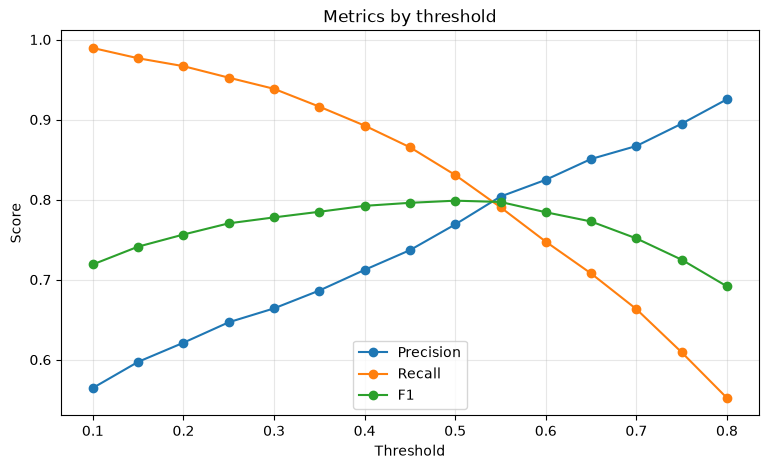

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics by threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [28]:
threshold_df.loc[
    threshold_df["f1"].idxmax()
]

threshold                     0.500000
precision                     0.768980
recall                        0.830750
f1                            0.798672
fp                         1771.000000
fn                         1201.000000
predicted_cancellations    7666.000000
predicted_share               0.424356
Name: 8, dtype: float64

In [29]:
candidates = threshold_df[
    threshold_df["recall"] >= 0.90
]

best_business_threshold = candidates.loc[
    candidates["precision"].idxmax()
]

best_business_threshold

threshold                     0.350000
precision                     0.686411
recall                        0.916150
f1                            0.784813
fp                         2970.000000
fn                          595.000000
predicted_cancellations    9471.000000
predicted_share               0.524273
Name: 5, dtype: float64

Подберем `threshold` более точно, используя `PR` кривую: 

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_proba
)

threshold_search = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

candidates = threshold_search[
    threshold_search["recall"] >= 0.90
]

best_threshold_row = candidates.loc[
    candidates["precision"].idxmax()
]

best_threshold_row

threshold    0.385739
precision    0.704799
recall       0.900366
Name: 7414, dtype: float64

Метрики для найденного порога:

In [31]:
best_threshold = best_threshold_row["threshold"]

val_pred_final = (
    val_proba >= best_threshold
).astype(int)

from sklearn.metrics import confusion_matrix, f1_score

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_pred_final
).ravel()

final_threshold_results = {
    "threshold": best_threshold,
    "precision": best_threshold_row["precision"],
    "recall": best_threshold_row["recall"],
    "f1": f1_score(y_val, val_pred_final),
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "tn": tn
}

final_threshold_results

{'threshold': np.float64(0.38573862884854593),
 'precision': np.float64(0.7047986762272477),
 'recall': np.float64(0.9003664036076663),
 'f1': 0.7906688942515934,
 'fp': np.int64(2676),
 'fn': np.int64(707),
 'tp': np.int64(6389),
 'tn': np.int64(8293)}

In [32]:
FINAL_THRESHOLD = float(best_threshold)

FINAL_THRESHOLD

0.38573862884854593

# Вывод
Стандартный `threshold` = 0.5 даёт максимальный `F1` = 0.799, но `Recall` составляет только 0.831. Для нашей задачи важнее не пропускать потенциальные отмены, поэтому использую `бизнес-критерий`: модель должна находить минимум 90% будущих отмен.

Среди порогов с Recall > 90% подбираю такой, где precision наибольший: threshold = 0.386